In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# titanic dataset

In [3]:
#чтение файла и просмотр загруженных данных
titanic_df = pd.read_csv('train.csv')
titanic_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
#исследование данных
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
#исследование данных: просмотр основных статистик
titanic_df.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [6]:
#исследование данных: просмотр основных статистик для категориальных переменных
titanic_df[titanic_df.select_dtypes(include=['object']).columns].describe().round(2)

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [7]:
#удаление лишних переменных
titanic_df_reduced = titanic_df.drop(columns=['PassengerId','Survived','Name','Ticket','Cabin'])
titanic_df_reduced.head(5)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [8]:
#исследование данных
titanic_df_reduced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       714 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  889 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 48.9+ KB


In [9]:
#исследование данных: просмотр основных статистик
titanic_df_reduced.describe().round(2)

,Pclass,Age,SibSp,Parch,Fare
count,891.00,714.00,891.00,891.00,891.00
mean,2.31,29.70,0.52,0.38,32.20
std,0.84,14.53,1.10,0.81,49.69
min,1.00,0.42,0.00,0.00,0.00
25%,2.00,20.12,0.00,0.00,7.91
50%,3.00,28.00,0.00,0.00,14.45
75%,3.00,38.00,1.00,0.00,31.00
max,3.00,80.00,8.00,6.00,512.33


In [10]:
#исследование данных: просмотр основных статистик для категориальных переменных
titanic_df_reduced[titanic_df_reduced.select_dtypes(include=['object']).columns].describe().round(2)

,Sex,Embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


In [11]:
#исследование данных: только пустые значения
titanic_df_reduced.isnull().sum()

,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [12]:
titanic_df_reduced = titanic_df_reduced.dropna()
titanic_df_reduced.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [13]:
from sklearn.preprocessing import LabelEncoder

# Кодирование категориальных переменных
label_encoder = LabelEncoder()
titanic_df_reduced['Sex'] = label_encoder.fit_transform(titanic_df_reduced['Sex'])
titanic_df_reduced['Embarked'] = label_encoder.fit_transform(titanic_df_reduced['Embarked'])

In [14]:
#исследование данных
titanic_df_reduced.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    712 non-null    int64  
 1   Sex       712 non-null    int64  
 2   Age       712 non-null    float64
 3   SibSp     712 non-null    int64  
 4   Parch     712 non-null    int64  
 5   Fare      712 non-null    float64
 6   Embarked  712 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 44.5 KB


In [15]:
#исследование данных: просмотр основных статистик
titanic_df_reduced.describe().round(2)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,712.00,712.00,712.00,712.00,712.00,712.00,712.00
mean,2.24,0.64,29.64,0.51,0.43,34.57,1.60
std,0.84,0.48,14.49,0.93,0.85,52.94,0.78
min,1.00,0.00,0.42,0.00,0.00,0.00,0.00
25%,1.00,0.00,20.00,0.00,0.00,8.05,2.00
50%,2.00,1.00,28.00,0.00,0.00,15.65,2.00
75%,3.00,1.00,38.00,1.00,1.00,33.00,2.00
max,3.00,1.00,80.00,5.00,6.00,512.33,2.00


In [16]:
from sklearn.preprocessing import StandardScaler

# Нормализация данных
scaler = StandardScaler()
titanic_df_reduced_scaled = scaler.fit_transform(titanic_df_reduced)
titanic_df_reduced_scaled

array([[ 0.90859974,  0.75613751, -0.52766856, ..., -0.50678737,
        -0.51637992,  0.51958818],
       [-1.48298257, -1.32251077,  0.57709388, ..., -0.50678737,
         0.69404605, -2.04948671],
       [ 0.90859974, -1.32251077, -0.25147795, ..., -0.50678737,
        -0.50362035,  0.51958818],
       ...,
       [-1.48298257, -1.32251077, -0.73481151, ..., -0.50678737,
        -0.08633507,  0.51958818],
       [-1.48298257,  0.75613751, -0.25147795, ..., -0.50678737,
        -0.08633507, -2.04948671],
       [ 0.90859974,  0.75613751,  0.16280796, ..., -0.50678737,
        -0.50692839, -0.76494927]])

In [17]:
from sklearn.cluster import DBSCAN, KMeans

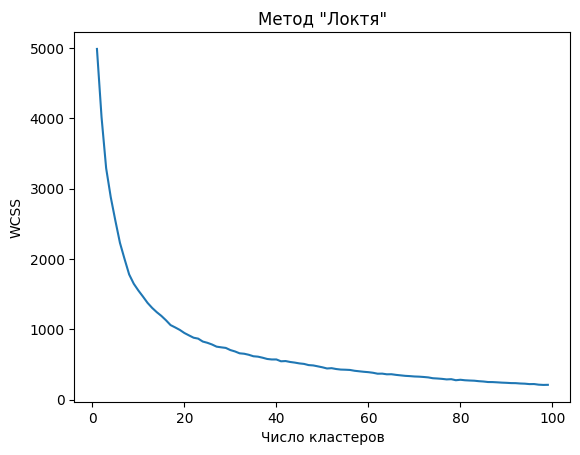

In [18]:
import warnings
warnings.filterwarnings('ignore')
wcss = []
t_max = 100

# Применим k-средних для k от 1 до 10
for i in range(1, t_max):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(titanic_df_reduced_scaled)
    wcss.append(kmeans.inertia_)
# Визуализация результатов

plt.plot(range(1, t_max), wcss)
plt.title('Метод "Локтя"')
plt.xlabel('Число кластеров')
plt.ylabel('WCSS')
plt.show()

In [19]:
# K-means кластеризация
kmeans = KMeans(n_clusters=10, random_state=42)
kmeans_labels = kmeans.fit_predict(titanic_df_reduced_scaled)
kmeans_labels

array([4, 7, 8, 8, 4, 5, 6, 9, 1, 3, 5, 4, 9, 8, 8, 6, 8, 2, 2, 8, 2, 6,
       9, 0, 7, 5, 7, 5, 4, 8, 1, 8, 8, 1, 8, 8, 6, 4, 7, 8, 7, 8, 1, 3,
       6, 1, 5, 6, 8, 4, 6, 4, 2, 6, 2, 1, 4, 4, 3, 8, 4, 4, 2, 8, 8, 9,
       0, 4, 4, 4, 5, 3, 5, 7, 7, 8, 2, 8, 2, 4, 4, 4, 8, 4, 5, 1, 4, 8,
       1, 4, 5, 2, 0, 6, 2, 1, 8, 5, 1, 4, 4, 1, 4, 8, 8, 2, 1, 9, 2, 4,
       7, 8, 8, 4, 2, 3, 4, 3, 9, 2, 5, 8, 4, 9, 7, 8, 4, 4, 8, 4, 4, 6,
       3, 9, 4, 5, 6, 3, 4, 7, 3, 7, 2, 4, 6, 3, 3, 5, 4, 4, 8, 2, 8, 3,
       7, 7, 4, 8, 4, 4, 1, 4, 3, 4, 1, 8, 7, 4, 8, 4, 2, 7, 8, 2, 7, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 8, 4, 5, 6, 2, 5, 3, 2, 2, 2, 4, 1, 7, 8,
       9, 2, 5, 8, 5, 4, 9, 1, 8, 0, 8, 6, 5, 2, 2, 6, 4, 0, 8, 4, 8, 7,
       5, 8, 6, 8, 5, 4, 4, 4, 1, 4, 4, 2, 8, 8, 7, 1, 8, 4, 1, 3, 0, 4,
       3, 7, 1, 7, 7, 0, 8, 4, 2, 8, 8, 5, 0, 7, 4, 4, 8, 8, 7, 5, 8, 8,
       7, 5, 0, 4, 2, 7, 4, 5, 3, 0, 2, 2, 2, 8, 8, 3, 4, 4, 1, 4, 4, 8,
       8, 9, 1, 1, 4, 4, 7, 7, 7, 4, 4, 7, 6, 8, 0,

In [20]:
titanic_df_reduced_scaled = pd.DataFrame(titanic_df_reduced_scaled,columns=titanic_df_reduced.columns)
titanic_df_reduced_scaled["kmeans_labels"]=kmeans_labels
titanic_df_reduced_scaled

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,kmeans_labels
0,0.908600,0.756138,-0.527669,0.522511,-0.506787,-0.516380,0.519588,4
1,-1.482983,-1.322511,0.577094,0.522511,-0.506787,0.694046,-2.049487,7
2,0.908600,-1.322511,-0.251478,-0.552714,-0.506787,-0.503620,0.519588,8
3,-1.482983,-1.322511,0.369951,0.522511,-0.506787,0.350326,0.519588,8
4,0.908600,0.756138,0.369951,-0.552714,-0.506787,-0.501257,0.519588,4
...,...,...,...,...,...,...,...,...
707,0.908600,-1.322511,0.646142,-0.552714,5.350885,-0.102875,-0.764949,9
708,-0.287191,0.756138,-0.182430,-0.552714,-0.506787,-0.407687,0.519588,2
709,-1.482983,-1.322511,-0.734812,-0.552714,-0.506787,-0.086335,0.519588,8
710,-1.482983,0.756138,-0.251478,-0.552714,-0.506787,-0.086335,-2.049487,7


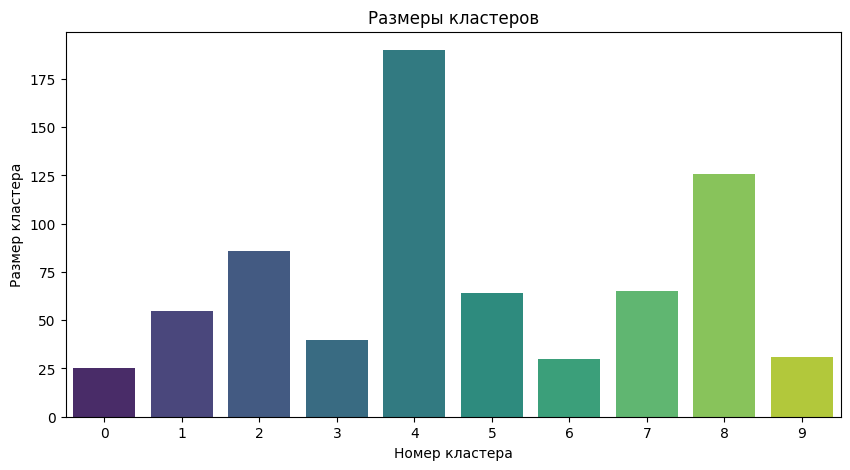

In [21]:
unique, counts = np.unique(kmeans_labels, return_counts=True)

plt.figure(figsize=(10, 5))
sns.barplot(x=unique, y=counts, palette='viridis')
plt.title('Размеры кластеров')
plt.xlabel('Номер кластера')
plt.ylabel('Размер кластера')
plt.show()

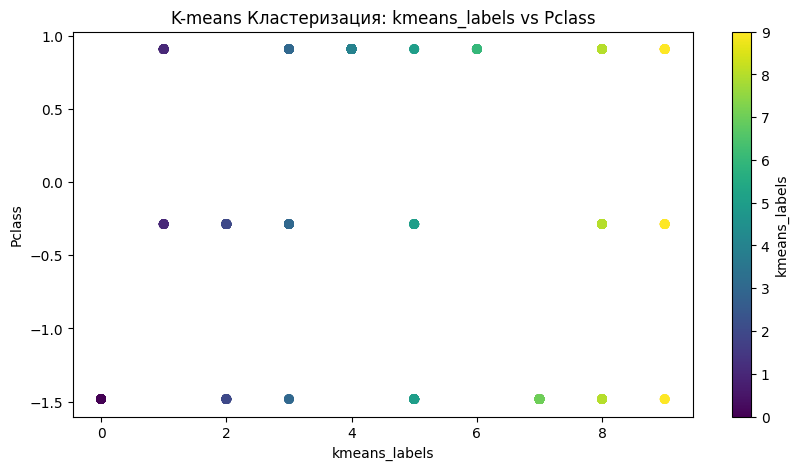

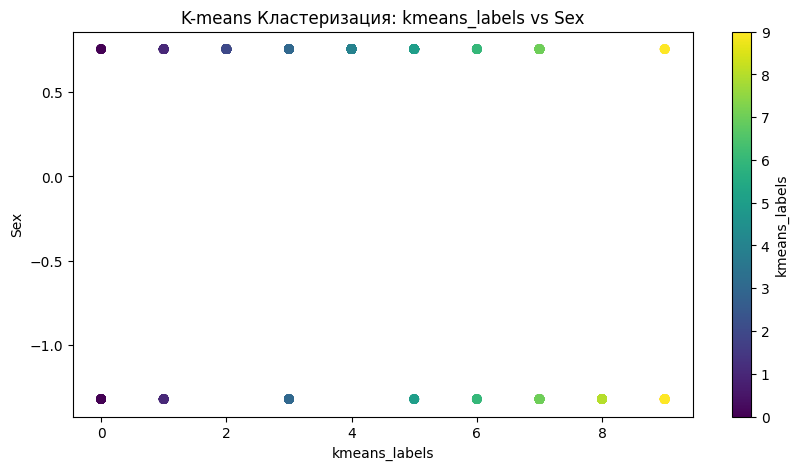

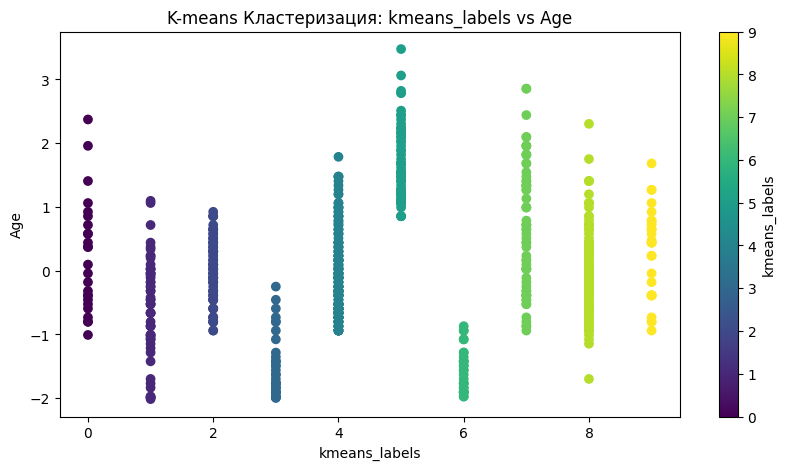

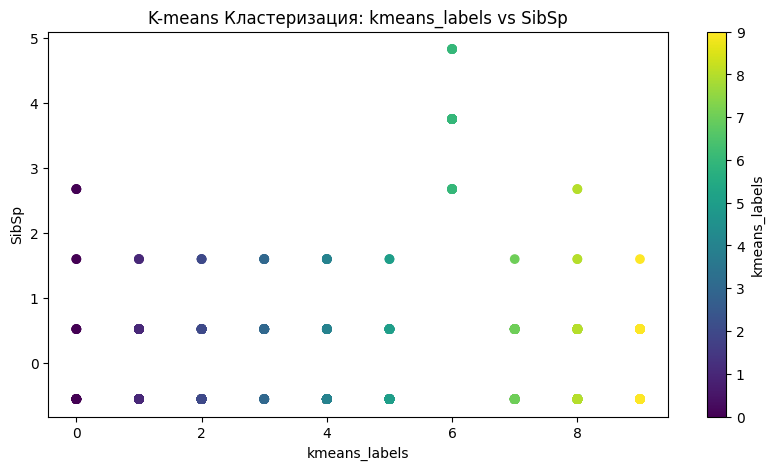

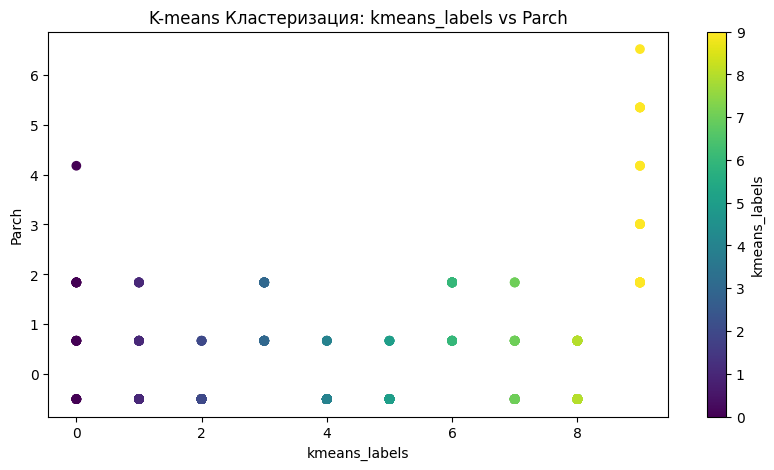

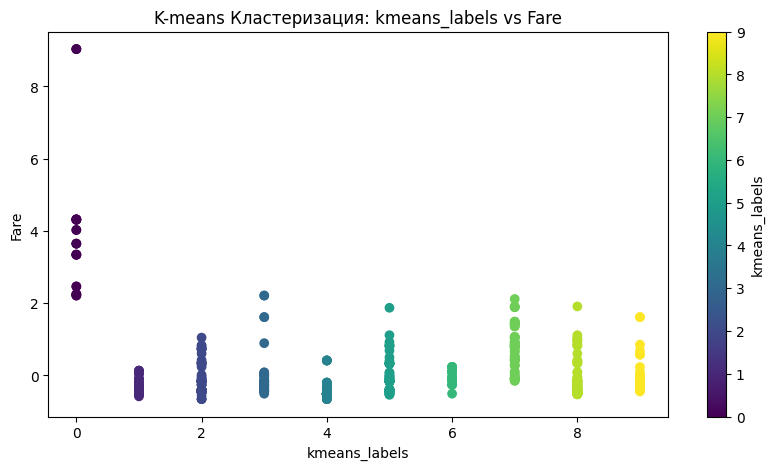

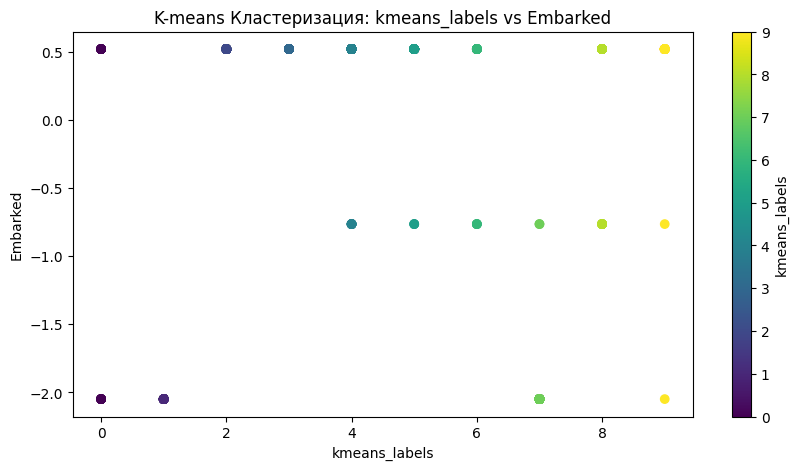

In [34]:
# Визуализация K-means
def visualization(var_x, var_y):
  plt.figure(figsize=(10, 5))
  plt.scatter(titanic_df_reduced_scaled[var_x], titanic_df_reduced_scaled[var_y], c=kmeans_labels, cmap='viridis')
  plt.title('K-means Кластеризация: ' + var_x + ' vs ' + var_y)
  plt.xlabel(var_x)
  plt.ylabel(var_y)
  plt.colorbar(label=var_x)
  plt.show()

visualization("kmeans_labels", "Pclass")
visualization("kmeans_labels", "Sex")
visualization("kmeans_labels", "Age")
visualization("kmeans_labels", "SibSp")
visualization("kmeans_labels", "Parch")
visualization("kmeans_labels", "Fare")
visualization("kmeans_labels", "Embarked")

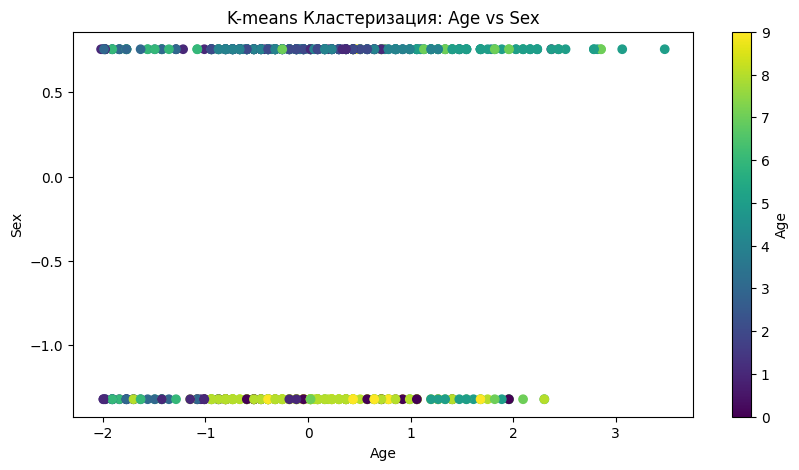

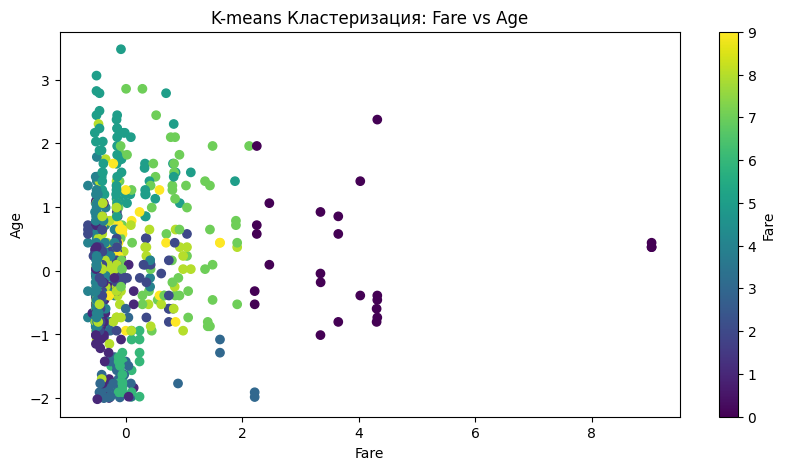

In [36]:
visualization("Age", "Sex")
visualization("Fare", "Age")

In [35]:
from sklearn.metrics import silhouette_score
from tqdm import tqdm

In [25]:
best_score = -100
silhouette_coefficients = {}

In [26]:
# Начинаем с минимума 2 кластеров, так как для одного кластера силуэтный коэффициент не определен
for j in tqdm(range(5,30)):
    for k in range(5,300,1):
        epsilon = k/1000
        dbscan = DBSCAN(eps=epsilon, min_samples=j)
        clusters = dbscan.fit_predict(titanic_df_reduced_scaled)
        try:
            score = silhouette_score(titanic_df_reduced_scaled, clusters)
            silhouette_coefficients[epsilon] = {j,score}
        except:
            continue
        if score > best_score:
            best_score = score
            best_params = {j,score}


100%|██████████| 25/25 [03:06<00:00,  7.44s/it]


In [27]:
silhouette_coefficients

{0.005: {np.float64(-0.2688881946383787), 8},
 0.006: {np.float64(-0.2688881946383787), 8},
 0.007: {np.float64(-0.2688881946383787), 8},
 0.008: {np.float64(-0.2849808379585762), 9},
 0.009: {np.float64(-0.2849808379585762), 9},
 0.01: {np.float64(-0.2823019715491989), 9},
 0.011: {np.float64(-0.26617088111577075), 9},
 0.012: {np.float64(-0.27967893165667795), 10},
 0.013: {np.float64(-0.27967893165667795), 10},
 0.014: {np.float64(-0.27967893165667795), 11},
 0.015: {np.float64(-0.27967893165667795), 11},
 0.016: {np.float64(-0.27967893165667795), 11},
 0.017: {np.float64(-0.27967893165667795), 11},
 0.018: {np.float64(-0.27967893165667795), 11},
 0.019: {np.float64(-0.27967893165667795), 11},
 0.02: {np.float64(-0.27967893165667795), 11},
 0.021: {np.float64(-0.27967893165667795), 11},
 0.022: {np.float64(-0.27967893165667795), 11},
 0.023: {np.float64(-0.27967893165667795), 11},
 0.024: {np.float64(-0.27967893165667795), 11},
 0.025: {np.float64(-0.2605023226071015), 11},
 0.026: 

In [28]:
# DBSCAN кластеризация
dbscan = DBSCAN(eps=1, min_samples=10)
dbscan_labels = dbscan.fit_predict(titanic_df_reduced_scaled)
dbscan_labels


array([ 0, -1,  1, -1,  2,  3, -1, -1, -1, -1, -1,  2, -1,  1,  7, -1,  4,
        5,  5, -1,  6, -1, -1, -1, -1,  9, -1, -1,  2, -1, -1,  4, -1, -1,
       -1,  4, -1,  2, -1, -1, -1,  7,  8, -1, -1,  8, -1, -1,  7,  2, -1,
       -1,  5, -1,  5, -1,  2,  2, -1,  1,  2,  2,  6,  7, -1, -1, -1,  2,
        2,  2, -1, -1, -1, -1, -1, -1, -1,  1, -1,  2, -1,  2,  1,  2,  3,
       -1,  2,  4, -1,  2, -1, -1, -1, -1, -1, -1,  7, -1, -1,  2,  2,  8,
        2, -1, -1,  5, -1, -1, -1,  2, -1,  1,  4, -1,  5, -1,  2, -1, -1,
        5,  9, -1,  2, -1, -1, -1,  2, -1,  7,  2,  2, -1, -1, -1,  2,  3,
       -1, -1,  2, -1, -1, -1,  5,  2, -1, -1, -1,  3, -1,  2,  7,  5,  4,
       -1, -1, -1, -1,  7,  2,  2,  8,  2, -1,  0,  8, -1, -1,  2,  7,  2,
        5, -1,  1, -1, -1,  5,  2,  5,  2, -1,  2,  5,  2,  5, -1,  2,  9,
       -1,  5, -1, -1,  5,  5,  5,  2,  8, -1,  1, -1, -1, -1, -1,  3,  0,
       -1, -1, -1, -1, -1, -1, -1,  6,  5, -1,  0, -1, -1,  2, -1, -1, -1,
        1, -1, -1, -1,  2

In [29]:
titanic_df_reduced_scaled['dbscan_labels'] = dbscan_labels
titanic_df_reduced_scaled

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,kmeans_labels,dbscan_labels
0,0.908600,0.756138,-0.527669,0.522511,-0.506787,-0.516380,0.519588,4,0
1,-1.482983,-1.322511,0.577094,0.522511,-0.506787,0.694046,-2.049487,7,-1
2,0.908600,-1.322511,-0.251478,-0.552714,-0.506787,-0.503620,0.519588,8,1
3,-1.482983,-1.322511,0.369951,0.522511,-0.506787,0.350326,0.519588,8,-1
4,0.908600,0.756138,0.369951,-0.552714,-0.506787,-0.501257,0.519588,4,2
...,...,...,...,...,...,...,...,...,...
707,0.908600,-1.322511,0.646142,-0.552714,5.350885,-0.102875,-0.764949,9,-1
708,-0.287191,0.756138,-0.182430,-0.552714,-0.506787,-0.407687,0.519588,2,5
709,-1.482983,-1.322511,-0.734812,-0.552714,-0.506787,-0.086335,0.519588,8,-1
710,-1.482983,0.756138,-0.251478,-0.552714,-0.506787,-0.086335,-2.049487,7,-1


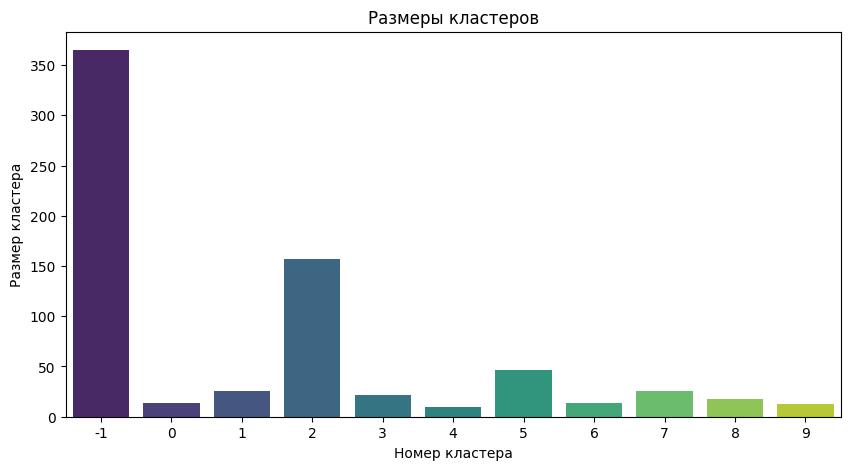

In [30]:
unique, counts = np.unique(dbscan_labels, return_counts=True)

plt.figure(figsize=(10, 5))
sns.barplot(x=unique, y=counts, palette='viridis')
plt.title('Размеры кластеров')
plt.xlabel('Номер кластера')
plt.ylabel('Размер кластера')
plt.show()

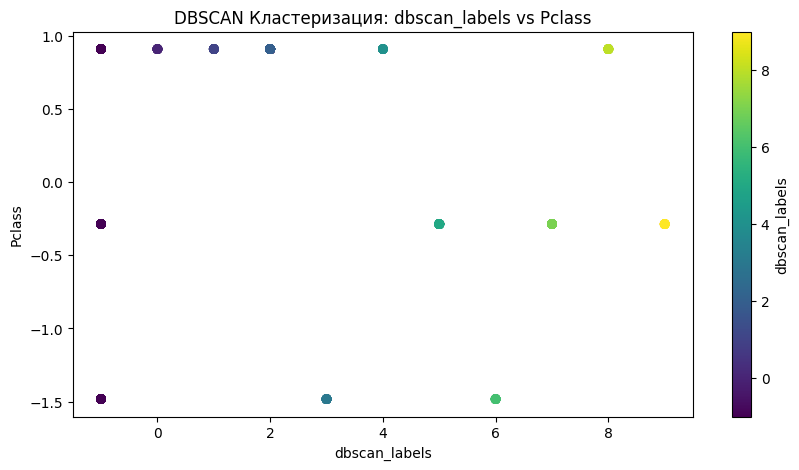

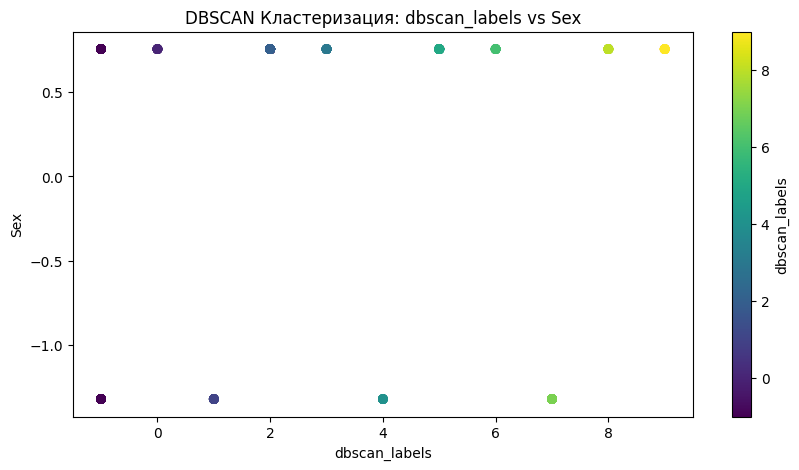

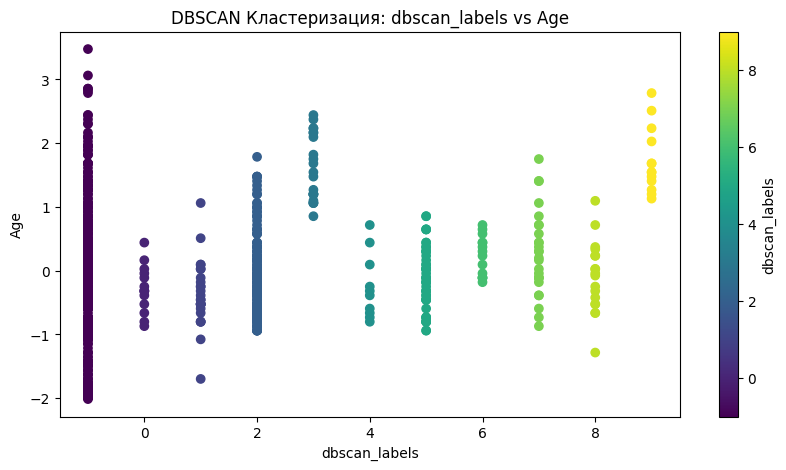

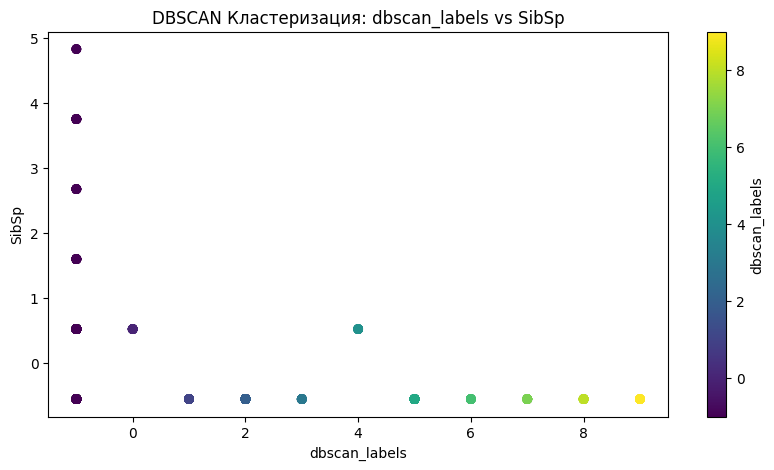

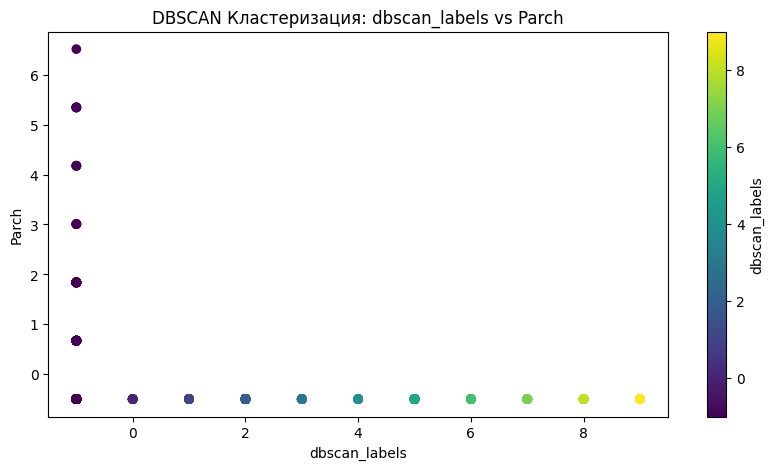

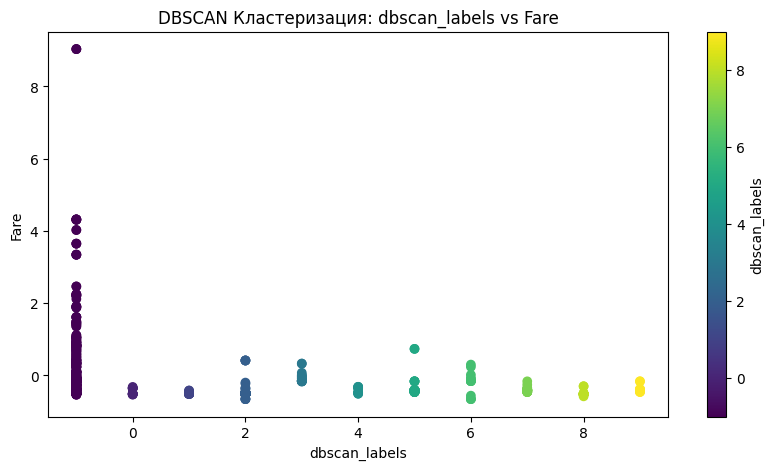

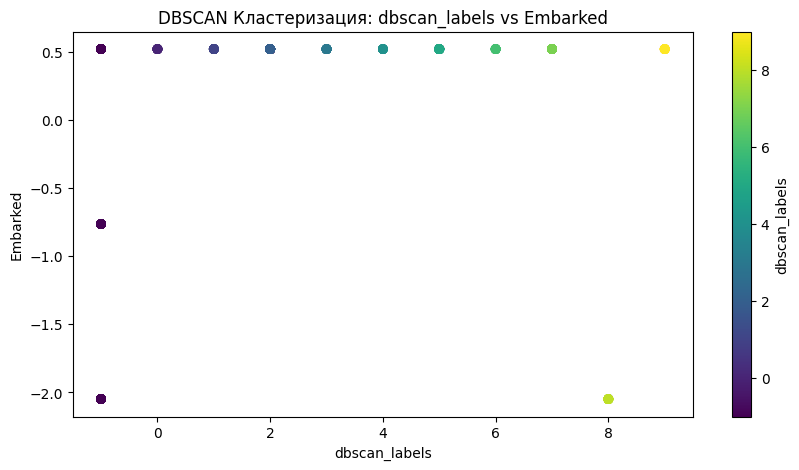

In [38]:
# Визуализация DBSCAN
def visualization(var_x, var_y):
  plt.figure(figsize=(10, 5))
  plt.scatter(titanic_df_reduced_scaled[var_x], titanic_df_reduced_scaled[var_y], c=dbscan_labels, cmap='viridis')
  plt.title('DBSCAN Кластеризация: ' + var_x + ' vs ' + var_y)
  plt.xlabel(var_x)
  plt.ylabel(var_y)
  plt.colorbar(label=var_x)
  plt.show()

visualization("dbscan_labels", "Pclass")
visualization("dbscan_labels", "Sex")
visualization("dbscan_labels", "Age")
visualization("dbscan_labels", "SibSp")
visualization("dbscan_labels", "Parch")
visualization("dbscan_labels", "Fare")
visualization("dbscan_labels", "Embarked")

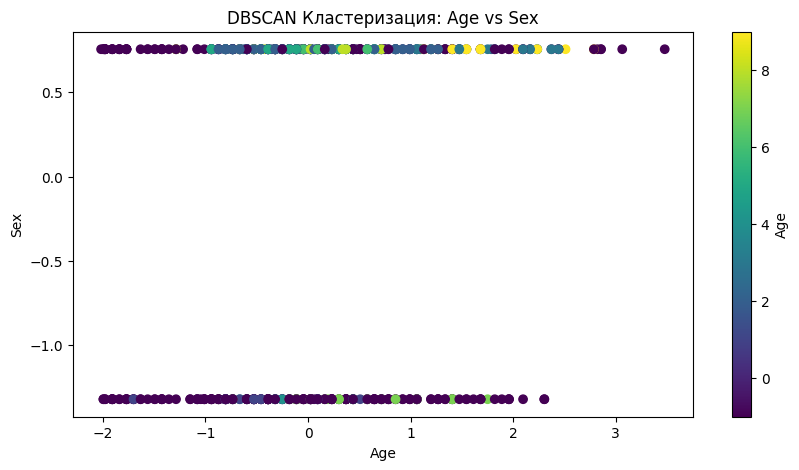

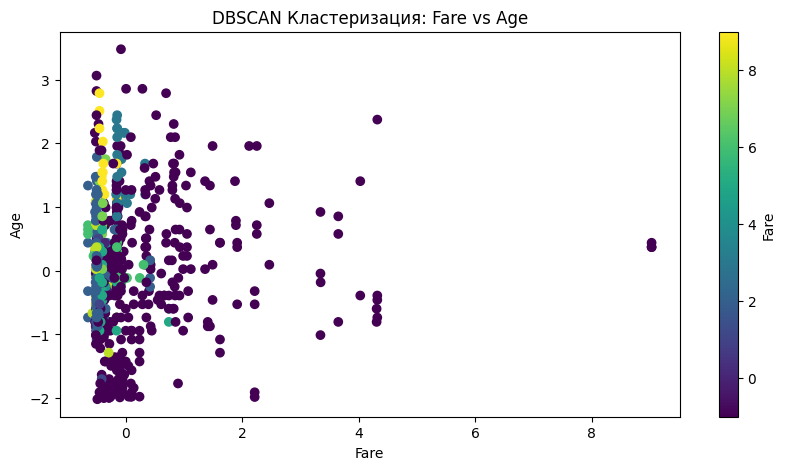

In [39]:
visualization("Age", "Sex")
visualization("Fare", "Age")